# Task 2: Product category clustering

**Goal:** group the products into 4-6 meaningful meta-categories using their text (reviews) and product characteristics (categories, names), then name each group.

**Why cluster products instead of reviews?** About 88% of the 34,660 reviews belong to just six products. If we clustered individual reviews, those products would dominate and small groups (chargers, cases) would vanish. So we build **one row per product** (about 40 rows), cluster those, and let every review inherit its product's cluster.

**Steps**
1. Load the raw data and apply the same light cleaning as before
2. Build a product table and clean the product names
3. Sanity-check what each product really is, using the reviews
4. Build product features: category text + review embeddings
5. Choose the number of clusters (k = 4 to 6)
6. Fit the clusters and look at them
7. Profile and name the clusters
8. Assign clusters back to the reviews and save

## 1. Setup and load

Use the **raw** `1429_1.csv` here, not `reviews_clean.csv`, because we need the product columns (`asins`, `name`, `categories`) that the sentiment cleaning dropped.

Review embeddings use `sentence-transformers`. If the library isn't installed, the notebook falls back to TF-IDF so it still runs (the embeddings give better results).

In [1]:
# !pip install -q sentence-transformers

In [6]:
import re
import html
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import normalize

DATA_PATH = "../data/1429_1_R.csv"          # raw dataset; adjust the path to where the file is
SEED = 42
MIN_REVIEWS = 3                   # drop products with fewer reviews than this (too little text)
MAX_REVIEWS_PER_PRODUCT = 300     # reviews sampled per product for the embeddings
W_CAT, W_REV = 1.0, 1.0           # relative weight of category text vs review text
K_RANGE = range(2, 9)             # values of k to compare
STOP = list(ENGLISH_STOP_WORDS | {"br"})   # "br" is a leftover from HTML line breaks

In [7]:
raw = pd.read_csv(DATA_PATH, low_memory=False)
df = raw[["asins", "name", "brand", "categories",
          "reviews.rating", "reviews.title", "reviews.text"]].copy()
df.columns = ["asin", "name", "brand", "categories", "rating", "title", "body"]

def clean(text):
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["asin", "body", "rating"])
df = df[df["rating"].between(1, 5)]
df["title"] = df["title"].fillna("").map(clean)
df["body"] = df["body"].map(clean)
df["text"] = (df["title"] + ". " + df["body"]).str.strip(". ").str.strip()
df = df[df["text"].str.split().str.len() >= 3].drop_duplicates(subset=["text"]).reset_index(drop=True)
print("Reviews after cleaning:", len(df), "| products (asins):", df["asin"].nunique())

Reviews after cleaning: 34595 | products (asins): 38


## 2. Build the product table

The `name` column is unreliable: it is empty for about 20% of the rows, some products have many name variants, and some names are repeated with stray `,,,` and line breaks. We clean the variants and take the **most common** one per product. When a product has no name at all, we fall back to the brand.

In [8]:
def clean_name(n):
    if pd.isna(n):
        return None
    n = str(n).split("\r\n")[0]              # names are sometimes repeated after a line break
    n = re.sub(r",+\s*$", "", n).strip()      # trailing ",,,"
    return n[:70] if n else None

df["name_clean"] = df["name"].map(clean_name)

def top_name(s):
    s = s.dropna()
    return s.value_counts().index[0] if len(s) else None

products = df.groupby("asin").agg(
    n_reviews=("text", "size"),
    avg_rating=("rating", "mean"),
    brand=("brand", "first"),
    name=("name_clean", top_name),
    categories=("categories", "first"),
).reset_index()
products["name"] = products["name"].fillna(products["brand"].astype(str) + " (no name)")

dropped = products[products["n_reviews"] < MIN_REVIEWS]
print(f"Dropping {len(dropped)} products with fewer than {MIN_REVIEWS} reviews:")
print(dropped[["asin", "n_reviews", "categories"]].to_string(index=False))

products = products[products["n_reviews"] >= MIN_REVIEWS].sort_values("n_reviews", ascending=False).reset_index(drop=True)
print("\nProducts kept:", len(products))
products[["asin", "n_reviews", "avg_rating", "name"]].head(15).round(2)

Dropping 2 products with fewer than 3 reviews:
      asin  n_reviews                                                    categories
B00DU15MU4          1 Electronics,Categories,Streaming Media Players,Amazon Devices
B018Y23P7K          1     Fire Tablets,Tablets,Computers & Tablets,All Tablets,Frys

Products kept: 36


,asin,n_reviews,avg_rating,name
0,B018Y229OU,10961,4.45,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes..."
1,"B00L9EPT8O,B01E6AO69U",6618,4.67,Echo (White)
2,B00U3FPN4U,5054,4.71,Amazon Fire Tv (no name)
3,B00OQVZDJM,3176,4.77,Amazon Kindle Paperwhite - eBook reader - 4 GB...
4,B01AHB9CN2,2812,4.59,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,..."
5,B018Y23MNM,1682,4.53,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16..."
6,B018Y225IA,1037,4.51,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...
7,B01BH83OOM,636,4.53,Amazon Echo (no name)
8,B00IOY8XWQ,580,4.73,"Kindle Voyage E-reader, 6 High-Resolution Disp..."
9,B01J2G4VBG,396,4.43,"All-New Kindle E-reader - Black, 6 Glare-Free ..."


## 3. Sanity check: what is each product, really?

Because names and categories are noisy, we check them against what reviewers actually write. For the largest products, this table shows the share of reviews that mention each device keyword. For example, if a product called "Echo (White)" has reviews that talk about "tablet" and "apps" and never "Alexa", the name is wrong.

In [9]:
KEYWORDS = ["alexa", "echo", "kindle", "paperwhite", "tablet", "fire tv", "remote",
            "kids", "charger", "case|cover", "read|book", "speaker|music"]

low = df["text"].str.lower()
top = products.head(15)
rows = {}
for _, p in top.iterrows():
    mask = df["asin"] == p["asin"]
    rows[f'{p["asin"][:10]} | {p["name"][:32]}'] = {
        kw: low[mask].str.contains(kw).mean() for kw in KEYWORDS}

check = pd.DataFrame(rows).T
check.style.format("{:.0%}").background_gradient(cmap="Blues", axis=None)

,alexa,echo,kindle,paperwhite,tablet,fire tv,remote,kids,charger,case|cover,read|book,speaker|music
"B018Y229OU | Fire Tablet, 7 Display, Wi-Fi, 8",0%,0%,12%,0%,56%,0%,0%,16%,0%,2%,19%,2%
B00L9EPT8O | Echo (White),30%,34%,0%,0%,0%,0%,1%,4%,0%,1%,4%,36%
B00U3FPN4U | Amazon Fire Tv (no name),3%,0%,0%,0%,0%,24%,6%,1%,0%,0%,3%,2%
B00OQVZDJM | Amazon Kindle Paperwhite - eBook,0%,0%,49%,20%,6%,0%,0%,1%,0%,3%,75%,0%
"B01AHB9CN2 | All-New Fire HD 8 Tablet, 8 HD D",1%,0%,18%,0%,51%,0%,0%,8%,0%,2%,24%,3%
"B018Y23MNM | Fire Kids Edition Tablet, 7 Disp",0%,0%,6%,0%,49%,0%,0%,43%,2%,11%,8%,1%
B018Y225IA | Brand New Amazon Kindle Fire 16g,0%,0%,17%,0%,51%,0%,0%,11%,0%,3%,26%,4%
B01BH83OOM | Amazon Echo (no name),29%,27%,0%,0%,0%,0%,0%,3%,1%,2%,6%,50%
"B00IOY8XWQ | Kindle Voyage E-reader, 6 High-R",0%,0%,51%,13%,4%,0%,0%,0%,0%,6%,69%,0%
"B01J2G4VBG | All-New Kindle E-reader - Black,",0%,0%,26%,3%,2%,0%,0%,0%,20%,1%,6%,0%


Use this table to spot mislabelled products. The review text is the most trustworthy signal we have, which is another reason to include it in the features.

## 4. Product features

Each product is described by two blocks of features:

1. **Category text:** the Amazon category path (for example "Fire Tablets, Tablets, Computers & Tablets"), turned into TF-IDF vectors. This captures product characteristics.
2. **Review text:** a sample of up to 300 reviews per product, embedded with a sentence-embedding model and averaged. Embeddings place similar meanings close together ("e-reader" near "Kindle"), which TF-IDF cannot do.

The two blocks are normalised and combined with the weights `W_CAT` and `W_REV`. Raise `W_REV` if categories mislead you (as with the "Echo" under tablet categories seen above).

In [10]:
# --- Block 1: category text ---
def cat_text(c):
    c = str(c).lower()
    return re.sub(r"[^a-z0-9, ]+", " ", c).replace(",", " , ")

cat_docs = products["categories"].map(cat_text)
cat_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, token_pattern=r"[a-z0-9]{2,}")
X_cat = cat_vec.fit_transform(cat_docs).toarray()
print("Category features:", X_cat.shape)

Category features: (36, 223)


In [11]:
# --- Block 2: review text ---
USE_EMBEDDINGS = True
rng = np.random.default_rng(SEED)

# shuffle, then keep the first MAX_REVIEWS_PER_PRODUCT reviews of each product
sample = (df[df["asin"].isin(products["asin"])]
          .sample(frac=1, random_state=SEED)
          .groupby("asin").head(MAX_REVIEWS_PER_PRODUCT)
          .copy())

try:
    if not USE_EMBEDDINGS:
        raise ImportError
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    emb = model.encode(sample["text"].tolist(), batch_size=64, show_progress_bar=True,
                       normalize_embeddings=True)
    emb_df = pd.DataFrame(emb, index=sample["asin"].values)
    X_rev = normalize(emb_df.groupby(level=0).mean().loc[products["asin"]].values)
    print("Review features: sentence embeddings", X_rev.shape)
except ImportError:
    print("sentence-transformers not available: using TF-IDF + SVD on the review text instead")
    docs = sample.groupby("asin")["text"].apply(" ".join).loc[products["asin"]]
    tf = TfidfVectorizer(stop_words=STOP, min_df=2, max_df=0.8, sublinear_tf=True)
    X_tf = tf.fit_transform(docs)
    n_comp = min(20, X_tf.shape[0] - 1)
    X_rev = normalize(TruncatedSVD(n_components=n_comp, random_state=SEED).fit_transform(X_tf))
    print("Review features: TF-IDF + SVD", X_rev.shape)

X = normalize(np.hstack([W_CAT * normalize(X_cat), W_REV * X_rev]))
print("Combined feature matrix:", X.shape)

sentence-transformers not available: using TF-IDF + SVD on the review text instead
Review features: TF-IDF + SVD (36, 20)
Combined feature matrix: (36, 243)


## 5. How many clusters?

We compare k from 2 to 8 with two algorithms (KMeans and Ward hierarchical clustering) and score them with the **silhouette score** (higher means tighter, better-separated clusters).

Treat the score with care: there are only about 40 products, so it is noisy, and the task requires 4-6 clusters anyway. The score helps choose *within* that range, but reading the clusters in the next section matters more.

,kmeans_silhouette,ward_silhouette
k,,
2,0.154,0.138
3,0.126,0.122
4,0.158,0.156
5,0.178,0.176
6,0.204,0.202
7,0.184,0.188
8,0.204,0.193


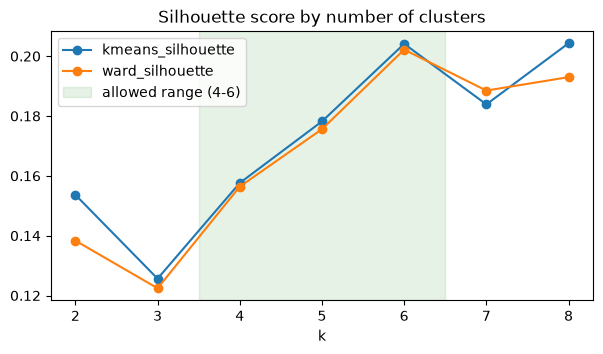

In [12]:
rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(X)
    ag = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X)
    rows.append({"k": k,
                 "kmeans_silhouette": silhouette_score(X, km.labels_),
                 "ward_silhouette": silhouette_score(X, ag.labels_)})

scores = pd.DataFrame(rows).set_index("k")
display(scores.round(3))

scores.plot(marker="o", figsize=(7, 3.5))
plt.axvspan(3.5, 6.5, alpha=0.1, color="green", label="allowed range (4-6)")
plt.title("Silhouette score by number of clusters"); plt.legend(); plt.show()

In [36]:
allowed = scores.loc[4:6, "kmeans_silhouette"]
K = int(allowed.idxmax())          # best KMeans silhouette within 4-6
#K = 5                         # override here if reading the clusters suggests a different k
print("Chosen k =", K)

Chosen k = 6


## 6. Fit the clusters and look at them

In [37]:
km = KMeans(n_clusters=K, n_init=50, random_state=SEED).fit(X)
ag = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X)
products["cluster"] = km.labels_

print("Agreement between KMeans and Ward (adjusted Rand index):",
      round(adjusted_rand_score(km.labels_, ag.labels_), 3), "(1.0 = identical)")

# ---- merge clusters that are too small into their nearest cluster ----
MIN_CLUSTER_REVIEWS = 100
labels = km.labels_.copy()
while True:
    sizes = products.groupby(labels)["n_reviews"].sum()
    if sizes.min() >= MIN_CLUSTER_REVIEWS or len(sizes) <= 4:
        break
    small = sizes.idxmin()
    c_small = X[labels == small].mean(axis=0)
    sims = {c: c_small @ X[labels == c].mean(axis=0) /
               (np.linalg.norm(c_small) * np.linalg.norm(X[labels == c].mean(axis=0)))
            for c in sizes.index if c != small}
    target = max(sims, key=sims.get)
    print(f"Merged cluster {small} ({sizes[small]} reviews) into cluster {target}")
    labels[labels == small] = target
labels = pd.factorize(labels)[0]       # renumber clusters 0, 1, 2, ...
products["cluster"] = labels
K = len(set(labels))
print("Final number of clusters:", K)
# ----------------------------------------------------------------------

for c in range(K):
    sub = products[products["cluster"] == c]
    print(f"\n=== Cluster {c}: {len(sub)} products, {sub['n_reviews'].sum()} reviews ===")
    print(sub[["asin", "n_reviews", "name"]].head(8).to_string(index=False))

Agreement between KMeans and Ward (adjusted Rand index): 0.917 (1.0 = identical)
Merged cluster 3 (34 reviews) into cluster 1
Final number of clusters: 5

=== Cluster 0: 13 products, 17605 reviews ===
      asin  n_reviews                                                                   name
B018Y229OU      10961 Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta
B01AHB9CN2       2812 All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Specia
B018Y23MNM       1682 Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Cas
B018Y225IA       1037 Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue
B00TSUGXKE        369                                                           Echo (White)
B018SZT3BK        267   Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black
B0189XYY0Q        255                                                  Amazon Fire (no name)
B01AHB9CYG        158 All-New Fire HD 8 Tablet, 8 HD Di

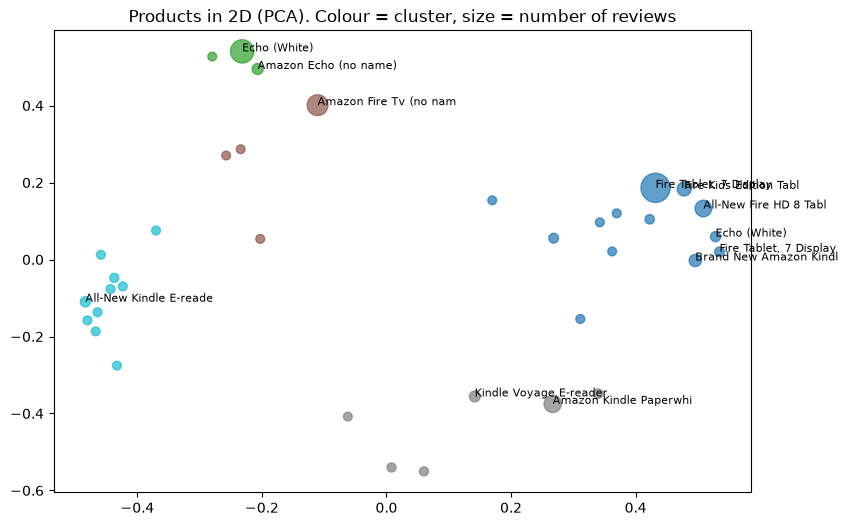

In [38]:
coords = PCA(n_components=2, random_state=SEED).fit_transform(X)
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=products["cluster"], cmap="tab10",
                s=40 + 400 * products["n_reviews"] / products["n_reviews"].max(), alpha=0.7)
for i in range(min(12, len(products))):                # label the biggest products
    ax.annotate(products["name"][i][:22], coords[i], fontsize=8)
ax.set_title("Products in 2D (PCA). Colour = cluster, size = number of reviews")
plt.show()

## 7. Profile and name the clusters

For each cluster we look at three things: its **most distinctive review words** (TF-IDF over the cluster's reviews, ignoring words common to all clusters), its **most common Amazon categories**, and its **products**. Use these to decide on a name.

In [39]:
prod2cluster = dict(zip(products["asin"], products["cluster"]))
sample["cluster"] = sample["asin"].map(prod2cluster)

cluster_docs = sample.groupby("cluster")["text"].apply(" ".join).sort_index()
tf = TfidfVectorizer(stop_words=STOP, max_df=0.6, min_df=1, sublinear_tf=True)
M = tf.fit_transform(cluster_docs)
terms = np.array(tf.get_feature_names_out())

for c in range(K):
    sub = products[products["cluster"] == c]
    top_terms = terms[np.argsort(M[c].toarray()[0])[-12:][::-1]]
    cats = Counter()
    for s in sub["categories"]:
        cats.update({x.strip() for x in str(s).split(",") if x.strip()})
    top_cats = [f"{k} ({v}/{len(sub)})" for k, v in cats.most_common(6)]
    print(f"--- Cluster {c} | {len(sub)} products | {sub['n_reviews'].sum()} reviews "
          f"| avg rating {np.average(sub['avg_rating'], weights=sub['n_reviews']):.2f}")
    print("  Review words:", ", ".join(top_terms))
    print("  Categories:  ", "; ".join(top_cats))
    print("  Products:    ", " | ".join(sub["name"].str[:30].head(4)), "\n")

--- Cluster 0 | 13 products | 17605 reviews | avg rating 4.49
  Review words: grandson, yr, videos, surf, gb, granddaughter, parental, hd8, tablets, age, inexpensive, movies
  Categories:   Tablets (13/13); Computers & Tablets (13/13); All Tablets (12/13); Fire Tablets (10/13); Electronics (6/13); iPad & Tablets (4/13)
  Products:     Fire Tablet, 7 Display, Wi-Fi, | All-New Fire HD 8 Tablet, 8 HD | Fire Kids Edition Tablet, 7 Di | Brand New Amazon Kindle Fire 1 

--- Cluster 1 | 3 products | 7261 reviews | avg rating 4.66
  Review words: speaker, dot, echo, tap, commands, automation, bass, voice, garage, answer, speakers, sounds
  Categories:   Home Automation (3/3); Alarms & Sensors (3/3); Electronics (3/3); Smart Home (3/3); Amazon Devices (3/3); Voice Assistants (3/3)
  Products:     Echo (White) | Amazon Echo (no name) | Amazon (no name) 

--- Cluster 2 | 4 products | 5080 reviews | avg rating 4.70
  Review words: firetv, vue, remote, firestick, streaming, 4k, roku, youll, playsta

**A warning about product names.** Names often contradict the categories and the reviews. For example, the product `B01J2G4VBG` is described by its categories and reviews as a charger, but its most common name is a "Kindle E-reader". The clusters come from categories and review text, so they are usually right where the name is wrong. When naming clusters, trust the review words and categories above the product names.

**Now name the clusters.** Read the output above and fill in the dictionary below, using the cluster numbers you see. The names here are placeholders. Good names are short and describe what a customer would call the group (for example "Fire tablets", "E-readers", "Smart speakers", "Streaming devices", "Accessories"). Cluster numbers can change between runs, so always check them against the output first.

In [40]:
#CLUSTER_NAMES = {c: f"Cluster {c}" for c in range(K)}   # placeholders, replace after reading the profiles
# Example:
CLUSTER_NAMES = {
    0: "Fire tablets",
    1: "Smart speakers (Echo)",
    2: "Streaming devices (Fire TV)",
    3: "E-readers (Kindle)",
    4: "Accessories",
}

## 8. Assign clusters to every review and save

Every review gets the cluster of its product. These files are the input for Task 3 (the generated category articles).

In [41]:
products["cluster_name"] = products["cluster"].map(CLUSTER_NAMES)
df["cluster"] = df["asin"].map(prod2cluster)
df["cluster_name"] = df["cluster"].map(CLUSTER_NAMES)
reviews_out = df.dropna(subset=["cluster"]).copy()
reviews_out["cluster"] = reviews_out["cluster"].astype(int)

summary = (reviews_out.groupby("cluster_name")
           .agg(reviews=("text", "size"), products=("asin", "nunique"), avg_rating=("rating", "mean"))
           .sort_values("reviews", ascending=False))
display(summary.round(2))

products.to_csv("products_clustered.csv", index=False)
reviews_out[["asin", "name_clean", "rating", "text", "cluster", "cluster_name"]].to_csv(
    "reviews_clustered.csv", index=False)
print(f"Saved products_clustered.csv ({len(products)} rows) and reviews_clustered.csv ({len(reviews_out)} rows)")

,reviews,products,avg_rating
cluster_name,,,
Fire tablets,17605,13,4.49
Smart speakers (Echo),7261,3,4.66
Streaming devices (Fire TV),5080,4,4.70
E-readers (Kindle),4092,6,4.75
Accessories,555,10,4.29


Saved products_clustered.csv (36 rows) and reviews_clustered.csv (34593 rows)


## Summary

| Step | Decision | Why |
|---|---|---|
| Unit of clustering | Products (about 40), not reviews | Six products hold about 88% of reviews and would dominate a review-level clustering |
| Features | Category text (TF-IDF) + averaged review embeddings | Categories describe the product; reviews say what it really is, since names and categories are noisy |
| Algorithm | KMeans, checked against Ward hierarchical clustering | Simple, and the agreement between the two shows how stable the clusters are |
| Number of clusters | Best silhouette within 4-6, confirmed by reading the clusters | Required range, but the score is noisy with so few products |
| Output | `products_clustered.csv`, `reviews_clustered.csv` | Used by Task 3 |

**Limitations to mention in the write-up:** the dataset is almost entirely Amazon devices, so the meta-categories are device types rather than the very different product families (batteries, food, pet supplies) suggested in the brief. Accessories are rare and have few reviews, so their cluster is the least reliable. A few product names and categories contradict the review text, which is why the review embeddings carry half the weight.